In [1]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.transpiler import PassManager, CouplingMap
from qiskit.transpiler.passes import CommutativeCancellation, SabreSwap
from qiskit.circuit.library import CXGate, HGate

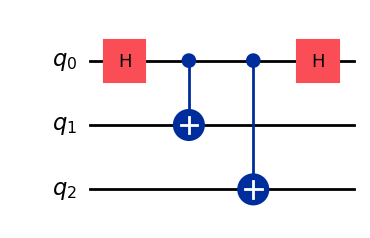

In [12]:
quantum_reg = QuantumRegister(3, "q")

circuit = QuantumCircuit(quantum_reg)
circuit.append(HGate(), [0])
circuit.append(CXGate(), [0, 1])
circuit.append(CXGate(), [0,2])
circuit.append(HGate(), [0])
circuit.draw("mpl")

Writing Custom Pass Manager for my above circuit

2


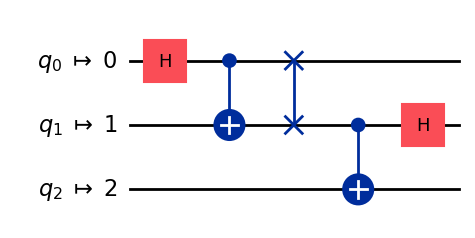

In [13]:
# Create a 7-qubit heavy-hex coupling map (free, no hardware access needed)
c_map = CouplingMap.from_line(num_qubits=3)
print(c_map.distance(0,2))


# Creating the passmanager and appending the passes
pass_manager = PassManager()
pass_manager.append(CommutativeCancellation())
pass_manager.append(SabreSwap(c_map))

transpiled_circuit = pass_manager.run(circuit)
transpiled_circuit.draw("mpl")